# ЛАБОРАТОРНАЯ РАБОТА №2. КЛАССИФИКАЦИЯ ИЗОБРАЖЕНИЙ С ИСПОЛЬЗОВАНИЕМ СВЕРТОЧНЫХ НЕЙРОННЫХ СЕТЕЙ

**Цель работы:** Изучить принципы работы сверточные нейронных сетей для классификации изображений, реализовать модель на основе transfer learning и провести эксперименты на данных.

**Задачи:**
1. Ознакомиться с сверточными нейросетями, с концепцией transfer learning и предобученными сверточными нейронными сетями.
2. Подготовить датасет, включая предобработку.
3. Обучить сверточную нейронную сеть.
4. Исследовать предложенные три архитектуры предобученных сетей, сравнить их результаты с вашей сверточной нейросетью.
5. Адаптировать предобученные модели под задачу классификации.
6. Провести обучение с замороженными и размороженными слоями.
7. Оценить качество моделей, вычислив метрики: Точность (Accuracy), Полноту (Recall), F1-score, Матрицу ошибок (Confusion Matrix).
8. Сравнить четыре модели между собой и определить лучшую для выбранной задачи.
9. Составить отчет с анализом результатов и выводами.

## 1. Загрузка данных

In [ ]:
import os
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Large, DenseNet121, ResNet18
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
from typing import Final

In [27]:
IMG_SIZE: Final[[int, int]] = (224, 224)
BATCH_SIZE: Final[int] = 32
EPOCHS: Final[int] = 10
NUM_CLASSES: Final[int] = 1
SEED: Final[int] = 123

In [28]:
def load_data(csv_path, images_dir):
    df = pd.read_csv(csv_path)
    
    sentiment_to_binary = {
        'very_positive': 1,
        'positive': 1,
        'neutral': 0,
        'negative': 0,
        'very_negative': 0
    }
    
    df['binary_sentiment'] = df['overall_sentiment'].map(sentiment_to_binary)
    
    df['image_path'] = df['image_name'].apply(lambda x: os.path.join(images_dir, x))
    df['image_exists'] = df['image_path'].apply(os.path.exists)
    df = df[df['image_exists']].reset_index(drop=True)

    def is_valid_image(image_path):
        try:
            img = tf.io.read_file(image_path)
            img = tf.image.decode_image(img, channels=3, expand_animations=False)
            if tf.shape(img)[0] == 0 or tf.shape(img)[1] == 0:
                return False
            return True
        except:
            return False
    
    valid_images = []
    for _, row in df.iterrows():
        if is_valid_image(row['image_path']):
            valid_images.append(True)
        else:
            valid_images.append(False)
            print(f"Поврежденное изображение: {row['image_name']}")
    
    df = df[valid_images].reset_index(drop=True)
    
    print(f"Всего загружено изображений: {len(df)}")
    print(f"Позитивных: {(df['binary_sentiment']==1).sum()}")
    print(f"Негативных: {(df['binary_sentiment']==0).sum()}")
    
    file_paths = df['image_path'].values
    labels = df['binary_sentiment'].values.astype(np.float32)
    
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    
    def load_and_preprocess_image(file_path, label):
        image = tf.io.read_file(file_path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, IMG_SIZE)
        image = tf.cast(image, tf.float32)
        image = preprocess_input(image)
        return image, label
    
    dataset = dataset.map(load_and_preprocess_image, 
                         num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset_size = len(df)
    train_size = int(0.8 * dataset_size)
    
    dataset = dataset.shuffle(buffer_size=dataset_size, seed=SEED)
    
    train_ds = dataset.take(train_size)
    val_ds = dataset.skip(train_size)
    
    train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    
    return train_ds, val_ds

csv_path = "memotion_dataset_7k/labels.csv"
images_dir = "memotion_dataset_7k/images"

train_ds, val_ds = load_data(csv_path, images_dir)

Поврежденное изображение: image_5119.png
Всего загружено изображений: 6991
Позитивных: 4159
Негативных: 2832


## 2. Обучение собственной CNN

In [29]:
inputs = keras.layers.Input(shape=(*IMG_SIZE, 3))

x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation='sigmoid')(x)


In [30]:
model = keras.Model(inputs, outputs)
model.summary()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.BinaryAccuracy(name='binary_accuracy')]
)

history = model.fit(
    train_ds, 
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 98s 470ms/step - accuracy: 0.5635 - auc: 0.4978 - binary_accuracy: 0.5635 - loss: 0.8845 - precision: 0.5965 - recall: 0.8392 - val_accuracy: 0.5926 - val_auc: 0.5080 - val_binary_accuracy: 0.5926 - val_loss: 0.6768 - val_precision: 0.5926 - val_recall: 1.0000
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 110s 565ms/step - accuracy: 0.5873 - auc: 0.5116 - binary_accuracy: 0.5873 - loss: 0.6794 - precision: 0.5952 - recall: 0.9631 - val_accuracy: 0.6097 - val_auc: 0.4904 - val_binary_accuracy: 0.6097 - val_loss: 0.6704 - val_precision: 0.6097 - val_recall: 1.0000
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 111s 556ms/step - accuracy: 0.5910 - auc: 0.4988 - binary_accuracy: 0.5910 - loss: 0.6797 - precision: 0.5914 - recall: 0.9955 - val_accuracy: 0.6047 - val_auc: 0.5148 - val_binary_accuracy: 0.6047 - val_loss: 0.6715 - val_precision: 0.6047 - val_recall: 1.0000
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 98s 495ms/step - accuracy: 0.6009 - auc: 0.4954 - binar

In [31]:
def evaluate_model(model, dataset=val_ds, threshold=0.5):
    y_true = []
    y_pred_probs = []
    
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)

        y_true.extend(labels.numpy().flatten())
        y_pred_probs.extend(predictions.flatten())
        
    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = (y_pred_probs > threshold).astype(int)
    
    accuracy = accuracy_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nМатрица ошибок:")
    print(conf_matrix)


In [32]:
evaluate_model(model)

Accuracy:  0.5761
Recall:    1.0000
F1-Score:  0.7311

Матрица ошибок:
[[  0 593]
 [  0 806]]


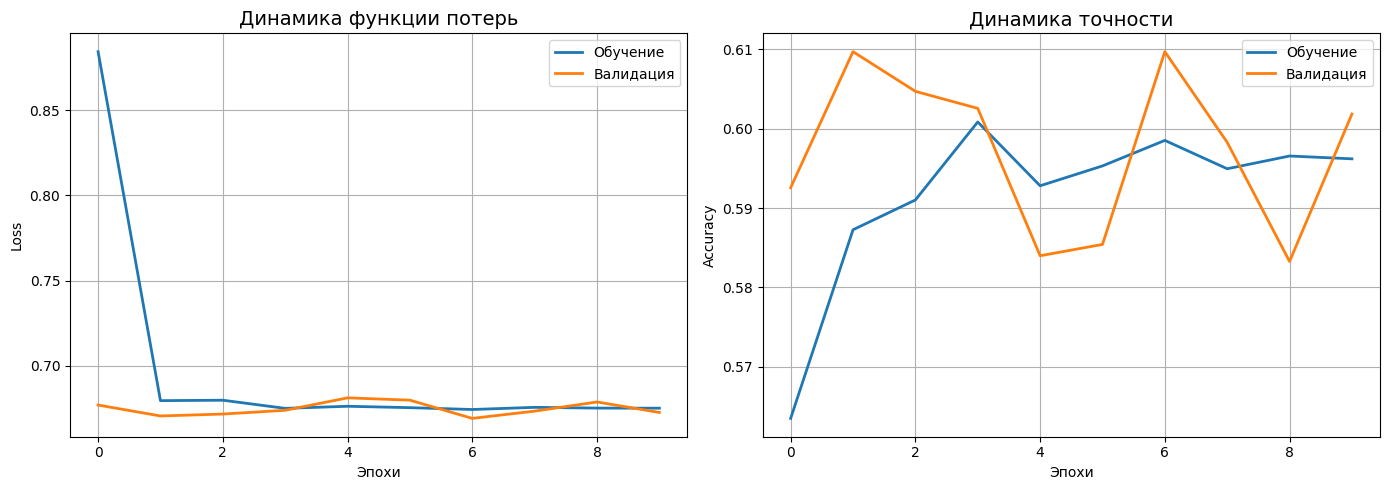

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['loss'], label='Обучение', linewidth=2)
ax1.plot(history.history['val_loss'], label='Валидация', linewidth=2)
ax1.set_title('Динамика функции потерь', fontsize=14)
ax1.set_xlabel('Эпохи')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['accuracy'], label='Обучение', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Валидация', linewidth=2)
ax2.set_title('Динамика точности', fontsize=14)
ax2.set_xlabel('Эпохи')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 3. Предобученные модели

In [ ]:
rn_base_model = ResNet18(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

rn_base_model.trainable = False

rn_model = keras.Sequential([
    rn_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='sigmoid')
])

rn_model.compile(
    optimizer="adam", 
    loss="binary_crossentropy", 
    metrics=["accuracy",
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')]
)

rn_history = rn_model.fit(
    train_ds, 
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.5583 - auc: 0.4989 - loss: 0.7450 - precision: 0.5905 - recall: 0.8323 - val_accuracy: 0.5940 - val_auc: 0.5820 - val_loss: 0.6712 - val_precision: 0.5928 - val_recall: 1.0000
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.5966 - auc: 0.5458 - loss: 0.6722 - precision: 0.6064 - recall: 0.9415 - val_accuracy: 0.6069 - val_auc: 0.6423 - val_loss: 0.6681 - val_precision: 0.5998 - val_recall: 0.9642
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.6016 - auc: 0.5748 - loss: 0.6671 - precision: 0.6078 - recall: 0.9383 - val_accuracy: 0.6197 - val_auc: 0.6651 - val_loss: 0.6546 - val_precision: 0.6275 - val_recall: 0.9100
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.6085 - auc: 0.6024 - loss: 0.6589 - precision: 0.6149 - recall: 0.9134 - val_accuracy: 0.6212 - val_auc: 0.6790 - val_loss: 0.6383 - val_precision: 0.6171 - val_recall: 0.9443
Epoch 5/10
175/175 ━━━━━━━━━

In [35]:
evaluate_model(rn_model)

Accuracy:  0.8013
Recall:    0.8599
F1-Score:  0.8378

Матрица ошибок:
[[403 161]
 [117 718]]


In [ ]:
mn_base_model = MobileNetV3Large(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

mn_base_model.trainable = False

mn_model = keras.Sequential([
    mn_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='sigmoid')
])

mn_model.compile(
    optimizer="adam", 
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

mn_history = mn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 47s 197ms/step - accuracy: 0.5603 - auc: 0.5222 - loss: 0.7447 - precision: 0.6098 - recall: 0.7372 - val_accuracy: 0.5911 - val_auc: 0.5242 - val_loss: 0.6764 - val_precision: 0.5944 - val_recall: 0.9759
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 176ms/step - accuracy: 0.5760 - auc: 0.5182 - loss: 0.6843 - precision: 0.5964 - recall: 0.8815 - val_accuracy: 0.6054 - val_auc: 0.5717 - val_loss: 0.6771 - val_precision: 0.6058 - val_recall: 0.9881
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 44s 185ms/step - accuracy: 0.5780 - auc: 0.5156 - loss: 0.6814 - precision: 0.5959 - recall: 0.9092 - val_accuracy: 0.6083 - val_auc: 0.5749 - val_loss: 0.6691 - val_precision: 0.6079 - val_recall: 0.9988
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 178ms/step - accuracy: 0.5851 - auc: 0.5246 - loss: 0.6782 - precision: 0.5930 - recall: 0.9473 - val_accuracy: 0.6112 - val_auc: 0.5699 - val_loss: 0.6681 - val_precision: 0.6112 - val_recall: 1.0000
Epoch 5/10
175/175 ━

In [46]:
evaluate_model(mn_model)

Accuracy:  0.6283
Recall:    0.9897
F1-Score:  0.7681

Матрица ошибок:
[[ 18 511]
 [  9 861]]


In [47]:
dn_base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

dn_base_model.trainable = False

dn_model = keras.Sequential([
    dn_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation = 'sigmoid')
])

dn_model.compile(
    optimizer="adam", 
    loss="binary_crossentropy", 
    metrics=["accuracy",
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')]
)

dn_history = dn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.5254 - auc: 0.5060 - loss: 2.3407 - precision: 0.5982 - recall: 0.6162 - val_accuracy: 0.6133 - val_auc: 0.4936 - val_loss: 0.6874 - val_precision: 0.6208 - val_recall: 0.9642
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.5730 - auc: 0.4978 - loss: 0.7225 - precision: 0.5992 - recall: 0.8640 - val_accuracy: 0.5954 - val_auc: 0.5173 - val_loss: 0.6844 - val_precision: 0.5954 - val_recall: 1.0000
Epoch 3/10


KeyboardInterrupt: 

In [39]:
evaluate_model(dn_model)

Accuracy:  0.5776
Recall:    1.0000
F1-Score:  0.7322

Матрица ошибок:
[[  0 591]
 [  0 808]]


## 4. Разморозка слоев

In [40]:
# Разморозка слоев ResNet18
rn_base_model.trainable = False
for layer in rn_base_model.layers[-4:]:
    layer.trainable = True

rn_model = keras.Sequential([
    rn_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='sigmoid')
])

rn_model.compile(
    optimizer="adam", 
    loss="binary_crossentropy", 
    metrics=["accuracy",
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')]
)

rn_history = rn_model.fit(
    train_ds, 
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/10


175/175 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.6091 - auc: 0.6178 - loss: 0.6869 - precision: 0.6440 - recall: 0.7664 - val_accuracy: 0.7155 - val_auc: 0.8117 - val_loss: 0.5635 - val_precision: 0.6991 - val_recall: 0.9316
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.6656 - auc: 0.7168 - loss: 0.6036 - precision: 0.6843 - recall: 0.8079 - val_accuracy: 0.7570 - val_auc: 0.8359 - val_loss: 0.5168 - val_precision: 0.7868 - val_recall: 0.8255
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.6919 - auc: 0.7490 - loss: 0.5752 - precision: 0.7156 - recall: 0.8017 - val_accuracy: 0.7920 - val_auc: 0.8842 - val_loss: 0.4799 - val_precision: 0.8005 - val_recall: 0.8564
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.7085 - auc: 0.7774 - loss: 0.5487 - precision: 0.7300 - recall: 0.8094 - val_accuracy: 0.8134 - val_auc: 0.9025 - val_loss: 0.4595 - val_precision: 0.7928 - val_recall: 0.9126
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━

In [41]:
evaluate_model(rn_model)

Accuracy:  0.9006
Recall:    0.9189
F1-Score:  0.9172

Матрица ошибок:
[[490  71]
 [ 68 770]]


In [42]:
# Разморозка MobilNetV3
mn_base_model.trainable = False
for layer in mn_base_model.layers[-4:]:
    layer.trainable = True

mn_model = keras.Sequential([
    mn_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='sigmoid'),
])

mn_model.compile(
    optimizer="adam", 
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

mn_history = mn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 49s 204ms/step - accuracy: 0.5506 - auc: 0.5003 - loss: 0.7427 - precision: 0.5956 - recall: 0.7609 - val_accuracy: 0.6054 - val_auc: 0.5542 - val_loss: 0.6698 - val_precision: 0.6052 - val_recall: 0.9976
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 43s 186ms/step - accuracy: 0.5851 - auc: 0.5364 - loss: 0.6795 - precision: 0.6010 - recall: 0.8958 - val_accuracy: 0.6112 - val_auc: 0.5712 - val_loss: 0.6704 - val_precision: 0.6120 - val_recall: 0.9835
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 47s 200ms/step - accuracy: 0.5892 - auc: 0.5337 - loss: 0.6748 - precision: 0.6028 - recall: 0.9308 - val_accuracy: 0.6276 - val_auc: 0.6035 - val_loss: 0.6603 - val_precision: 0.6252 - val_recall: 1.0000
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 48s 199ms/step - accuracy: 0.5903 - auc: 0.5370 - loss: 0.6752 - precision: 0.6016 - recall: 0.9318 - val_accuracy: 0.5804 - val_auc: 0.6146 - val_loss: 0.6720 - val_precision: 0.5789 - val_recall: 0.9963
Epoch 5/10
175/175 ━

In [43]:
evaluate_model(mn_model)

Accuracy:  0.6083
Recall:    0.9952
F1-Score:  0.7534

Матрица ошибок:
[[ 14 544]
 [  4 837]]


In [44]:
# Разморозка DenseNet121
dn_base_model.trainable = False
for layer in dn_base_model.layers[-4:]:
    layer.trainable = True

dn_model = keras.Sequential([
    dn_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='sigmoid'),
])

dn_model.compile(
    optimizer="adam", 
    loss="binary_crossentropy", 
    metrics=["accuracy",
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')]
)

dn_history = dn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.5492 - auc: 0.4933 - loss: 0.7311 - precision: 0.5898 - recall: 0.7910 - val_accuracy: 0.5683 - val_auc: 0.5310 - val_loss: 0.6856 - val_precision: 0.5900 - val_recall: 0.8333
Epoch 2/10
111/175 ━━━━━━━━━━━━━━━━━━━━ 1:16 1s/step - accuracy: 0.5703 - auc: 0.4854 - loss: 0.6884 - precision: 0.5871 - recall: 0.8922

KeyboardInterrupt: 

In [25]:
evaluate_model(dn_model)

Accuracy:  0.5697
Recall:    1.0000
F1-Score:  0.7259

Матрица ошибок:
[[  0 602]
 [  0 797]]
